In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import joblib, os
from tqdm.auto import tqdm
import sys

import os
import pandas as pd
# from scapy.all import rdpcap, TCP, IP, Ether, Raw

# !pip install tabulate
from tabulate import tabulate # For pretty-printing tabular data in console

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)


import time

# Import classifiers
from sklearn.ensemble import RandomForestClassifier

#import for preprocessing
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder, MinMaxScaler



# import methods for measuring accuracy, precision, recall etc
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [2]:
directory_path = '/content/drive/MyDrive/SytheticDataWatersDirectory'

In [3]:
df = pd.read_csv(f"{directory_path}/my_data_dnp3.csv")
print(f"Reloaded shape: {df.shape}")
df.head()

Reloaded shape: (834133, 36)


,source_file,frame.number,frame.time_epoch,frame.time_relative,frame.time_delta,frame.len,frame.cap_len,eth.src,eth.dst,ip.src,ip.dst,ip.proto,ip.ttl,tcp.srcport,tcp.dstport,tcp.flags,tcp.len,tcp.window_size_value,tcp.checksum,tcp.time_delta,dnp3_present,dnp3.start,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.prm,dnp3.fcb,dnp3.fcv,dnp3.func_code_link,dnp3.func_code,dnp3.func_name,dnp3.payload_len,dnp3.raw_hex,label
0,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,1,1.589556e+09,0.000000,NaN,84,84,be:0a:53:35:94:71,be:0a:53:15:bc:f6,192.168.1.1,192.168.1.5,6,64,41538,20001,24,18,312,24389,NaN,True,0x0564,11,196,13,2,1,1,0,0,4,1,READ,18,05640bc40d0002006db7cdcc013c0206505b,COLD_RESTART
1,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,2,1.589556e+09,0.000756,0.000756,83,83,be:0a:53:15:bc:f6,be:0a:53:35:94:71,192.168.1.5,192.168.1.1,6,64,20001,41538,24,17,227,7867,0.000756,True,0x0564,10,68,2,13,0,1,0,0,4,129,RESPONSE,17,05640a4402000d004ea8d2cc810000062d,COLD_RESTART
2,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,3,1.589556e+09,0.000836,0.000080,84,84,be:0a:53:35:94:71,be:0a:53:07:a6:60,192.168.1.1,192.168.1.9,6,64,51971,20001,24,18,312,49036,0.000080,True,0x0564,11,196,17,2,1,1,0,0,4,1,READ,18,05640bc4110002004e39cdcc013c0206505b,COLD_RESTART
3,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,4,1.589556e+09,0.001856,0.001020,84,84,be:0a:53:35:94:71,be:0a:50:6c:87:fa,192.168.1.1,192.168.1.4,6,64,45297,20001,24,18,312,56407,0.001020,True,0x0564,11,196,12,2,1,1,0,0,4,1,READ,18,05640bc40c0002008575cdcc013c0206505b,COLD_RESTART
4,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,5,1.589556e+09,0.002557,0.000701,83,83,be:0a:50:6c:87:fa,be:0a:53:35:94:71,192.168.1.4,192.168.1.1,6,64,20001,45297,24,17,227,561,0.000701,True,0x0564,10,68,2,12,0,1,0,0,4,129,RESPONSE,17,05640a4402000c000003d2cc810000062d,COLD_RESTART


In [4]:
df.columns

Index(['source_file', 'frame.number', 'frame.time_epoch',
       'frame.time_relative', 'frame.time_delta', 'frame.len', 'frame.cap_len',
       'eth.src', 'eth.dst', 'ip.src', 'ip.dst', 'ip.proto', 'ip.ttl',
       'tcp.srcport', 'tcp.dstport', 'tcp.flags', 'tcp.len',
       'tcp.window_size_value', 'tcp.checksum', 'tcp.time_delta',
       'dnp3_present', 'dnp3.start', 'dnp3.len', 'dnp3.ctrl', 'dnp3.dst_addr',
       'dnp3.src_addr', 'dnp3.dir', 'dnp3.prm', 'dnp3.fcb', 'dnp3.fcv',
       'dnp3.func_code_link', 'dnp3.func_code', 'dnp3.func_name',
       'dnp3.payload_len', 'dnp3.raw_hex', 'label'],
      dtype='object')

In [5]:
df['label'].value_counts()

,count
label,
DISABLE_UNSOLICITED,255326
COLD_RESTART,255276
WARM_RESTART,255276
INIT_DATA,30173
STOP_APP,30172
REPLAY,2882
DNP3_ENUMERATE,2249
20200516_DNP3_Ιnfo,2234
MITM_DOS,545


In [6]:
label_mapping = {

    # Restart Attacks (same behavior)
    'COLD_RESTART': 'RESTART_ATTACK',
    'WARM_RESTART': 'RESTART_ATTACK',

    # DNP3 Reconnaissance (same behavior)
    'DNP3_ENUMERATE': 'DNP3_RECON',
    '20200516_DNP3_Ιnfo': 'DNP3_RECON',

    # DoS / Disruption Attacks
    'MITM_DOS': 'DOS_ATTACK',
    'ARP_POISONING': 'DOS_ATTACK',

    # Control / Manipulation Attacks
    'DISABLE_UNSOLICITED': 'CONTROL_ATTACK',
    'STOP_APP': 'CONTROL_ATTACK',
    'INIT_DATA': 'CONTROL_ATTACK',

    # Replay Attack (unique)
    'REPLAY': 'REPLAY_ATTACK',
}

df['label'] = df['label'].map(label_mapping)

print(df['label'].value_counts())

label
RESTART_ATTACK    510552
CONTROL_ATTACK    315671
DNP3_RECON          4483
REPLAY_ATTACK       2882
DOS_ATTACK           545
Name: count, dtype: int64


In [7]:
print(df['label'].value_counts(normalize=True))

label
RESTART_ATTACK    0.612075
CONTROL_ATTACK    0.378442
DNP3_RECON        0.005374
REPLAY_ATTACK     0.003455
DOS_ATTACK        0.000653
Name: proportion, dtype: float64


In [8]:
df.columns

Index(['source_file', 'frame.number', 'frame.time_epoch',
       'frame.time_relative', 'frame.time_delta', 'frame.len', 'frame.cap_len',
       'eth.src', 'eth.dst', 'ip.src', 'ip.dst', 'ip.proto', 'ip.ttl',
       'tcp.srcport', 'tcp.dstport', 'tcp.flags', 'tcp.len',
       'tcp.window_size_value', 'tcp.checksum', 'tcp.time_delta',
       'dnp3_present', 'dnp3.start', 'dnp3.len', 'dnp3.ctrl', 'dnp3.dst_addr',
       'dnp3.src_addr', 'dnp3.dir', 'dnp3.prm', 'dnp3.fcb', 'dnp3.fcv',
       'dnp3.func_code_link', 'dnp3.func_code', 'dnp3.func_name',
       'dnp3.payload_len', 'dnp3.raw_hex', 'label'],
      dtype='object')

In [9]:
# Check if 20000 and 20003 exist in the dataframe at all
for port in [20000, 20001, 20002, 20003]:
    cnt = ((df["tcp.srcport"] == port) | (df["tcp.dstport"] == port)).sum()
    print(f"Port {port}: {cnt} packets")

Port 20000: 7910 packets
Port 20001: 413089 packets
Port 20002: 413134 packets
Port 20003: 0 packets


In [10]:
# Primary: use the dnp3_present flag (already parsed by your pipeline)
print("Packets with dnp3_present=True:", df["dnp3_present"].sum())

dnp3_df = df[df["dnp3_present"] == True].copy()
print(f"Filtered DNP3 packets (by dnp3_present): {len(dnp3_df)} / {len(df)} total packets")

Packets with dnp3_present=True: 834133
Filtered DNP3 packets (by dnp3_present): 834133 / 834133 total packets


In [11]:
# Cross-check: union with known DNP3 ports (20000, 20001, 20002)
dnp3_ports = {20000, 20001, 20002}
port_mask = df["tcp.srcport"].isin(dnp3_ports) | df["tcp.dstport"].isin(dnp3_ports)
flag_mask = df["dnp3_present"] == True

print("By port only:", port_mask.sum())
print("By flag only:", flag_mask.sum())
print("By port OR flag:", (port_mask | flag_mask).sum())
print("By port AND flag:", (port_mask & flag_mask).sum())
print("Port but NOT flagged:", (port_mask & ~flag_mask).sum())
print("Flagged but NOT in port range:", (flag_mask & ~port_mask).sum())

By port only: 834133
By flag only: 834133
By port OR flag: 834133
By port AND flag: 834133
Port but NOT flagged: 0
Flagged but NOT in port range: 0


In [12]:
print("Total rows in df:", len(df))
print("dnp3_present True:", (df["dnp3_present"] == True).sum())
print("dnp3_present False:", (df["dnp3_present"] == False).sum())
print("Unique dnp3.func_name values:", df["dnp3.func_name"].unique())

Total rows in df: 834133
dnp3_present True: 834133
dnp3_present False: 0
Unique dnp3.func_name values: ['READ' 'RESPONSE' 'COLD_RESTART' 'CONFIRM' 'DIRECT_OPERATE'
 'UNSOLICITED_RESPONSE' 'WARM_RESTART' 'STOP_APPL' 'INITIALIZE_DATA'
 'DISABLE_UNSOLICITED']


In [13]:
df.head()

,source_file,frame.number,frame.time_epoch,frame.time_relative,frame.time_delta,frame.len,frame.cap_len,eth.src,eth.dst,ip.src,ip.dst,ip.proto,ip.ttl,tcp.srcport,tcp.dstport,tcp.flags,tcp.len,tcp.window_size_value,tcp.checksum,tcp.time_delta,dnp3_present,dnp3.start,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.prm,dnp3.fcb,dnp3.fcv,dnp3.func_code_link,dnp3.func_code,dnp3.func_name,dnp3.payload_len,dnp3.raw_hex,label
0,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,1,1.589556e+09,0.000000,NaN,84,84,be:0a:53:35:94:71,be:0a:53:15:bc:f6,192.168.1.1,192.168.1.5,6,64,41538,20001,24,18,312,24389,NaN,True,0x0564,11,196,13,2,1,1,0,0,4,1,READ,18,05640bc40d0002006db7cdcc013c0206505b,RESTART_ATTACK
1,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,2,1.589556e+09,0.000756,0.000756,83,83,be:0a:53:15:bc:f6,be:0a:53:35:94:71,192.168.1.5,192.168.1.1,6,64,20001,41538,24,17,227,7867,0.000756,True,0x0564,10,68,2,13,0,1,0,0,4,129,RESPONSE,17,05640a4402000d004ea8d2cc810000062d,RESTART_ATTACK
2,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,3,1.589556e+09,0.000836,0.000080,84,84,be:0a:53:35:94:71,be:0a:53:07:a6:60,192.168.1.1,192.168.1.9,6,64,51971,20001,24,18,312,49036,0.000080,True,0x0564,11,196,17,2,1,1,0,0,4,1,READ,18,05640bc4110002004e39cdcc013c0206505b,RESTART_ATTACK
3,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,4,1.589556e+09,0.001856,0.001020,84,84,be:0a:53:35:94:71,be:0a:50:6c:87:fa,192.168.1.1,192.168.1.4,6,64,45297,20001,24,18,312,56407,0.001020,True,0x0564,11,196,12,2,1,1,0,0,4,1,READ,18,05640bc40c0002008575cdcc013c0206505b,RESTART_ATTACK
4,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,5,1.589556e+09,0.002557,0.000701,83,83,be:0a:50:6c:87:fa,be:0a:53:35:94:71,192.168.1.4,192.168.1.1,6,64,20001,45297,24,17,227,561,0.000701,True,0x0564,10,68,2,12,0,1,0,0,4,129,RESPONSE,17,05640a4402000c000003d2cc810000062d,RESTART_ATTACK


In [14]:
df = df[df["dnp3.func_code"].notna()].copy()
print(f"Filtered to {len(df)} packets with valid DNP3 function codes")

Filtered to 834133 packets with valid DNP3 function codes


In [15]:
# Fill missing dnp3.fcb/fcv with -1 (indicating "Not Applicable")
df['dnp3.fcb'] = df['dnp3.fcb'].fillna(-1)
df['dnp3.fcv'] = df['dnp3.fcv'].fillna(-1)

# Fill missing payload_len with 0
df['dnp3.payload_len'] = df['dnp3.payload_len'].fillna(0)

In [16]:
df.isnull().sum()

,0
source_file,0
frame.number,0
frame.time_epoch,0
frame.time_relative,0
frame.time_delta,1
frame.len,0
frame.cap_len,0
eth.src,0
eth.dst,0
ip.src,0


In [17]:
def drop_irrelevent_features(df, columns):
  df = df.drop(columns, axis = 1)
  return df

In [18]:
not_required_features = [
    "source_file",          # file identifier, not generalizable
    "frame.number",          # just a packet index
    "frame.time_epoch",      # absolute timestamp, not generalizable
    "eth.src",               # MAC address (identifier)
    "eth.dst",               # MAC address (identifier)
    "ip.src",                # IP address (identifier)
    "ip.dst",                # IP address (identifier)
    "tcp.checksum",          # validation checksum, no predictive value
    "dnp3.raw_hex",          # raw hex payload, too high-cardinality
]

df = drop_irrelevent_features(df, not_required_features)
df.shape

(834133, 27)

In [19]:
pd.set_option('display.max_columns', None)

In [20]:
df.head()

,frame.time_relative,frame.time_delta,frame.len,frame.cap_len,ip.proto,ip.ttl,tcp.srcport,tcp.dstport,tcp.flags,tcp.len,tcp.window_size_value,tcp.time_delta,dnp3_present,dnp3.start,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.prm,dnp3.fcb,dnp3.fcv,dnp3.func_code_link,dnp3.func_code,dnp3.func_name,dnp3.payload_len,label
0,0.000000,NaN,84,84,6,64,41538,20001,24,18,312,NaN,True,0x0564,11,196,13,2,1,1,0,0,4,1,READ,18,RESTART_ATTACK
1,0.000756,0.000756,83,83,6,64,20001,41538,24,17,227,0.000756,True,0x0564,10,68,2,13,0,1,0,0,4,129,RESPONSE,17,RESTART_ATTACK
2,0.000836,0.000080,84,84,6,64,51971,20001,24,18,312,0.000080,True,0x0564,11,196,17,2,1,1,0,0,4,1,READ,18,RESTART_ATTACK
3,0.001856,0.001020,84,84,6,64,45297,20001,24,18,312,0.001020,True,0x0564,11,196,12,2,1,1,0,0,4,1,READ,18,RESTART_ATTACK
4,0.002557,0.000701,83,83,6,64,20001,45297,24,17,227,0.000701,True,0x0564,10,68,2,12,0,1,0,0,4,129,RESPONSE,17,RESTART_ATTACK


In [21]:
df.isnull().sum()

,0
frame.time_relative,0
frame.time_delta,1
frame.len,0
frame.cap_len,0
ip.proto,0
ip.ttl,0
tcp.srcport,0
tcp.dstport,0
tcp.flags,0
tcp.len,0


In [22]:
# df['frame.time_delta'] = df['frame.time_delta'].fillna(0)
# df['tcp.time_delta'] = df['tcp.time_delta'].fillna(0)

df = df.dropna()

print(df.isnull().sum().sum(), "missing values remaining")

0 missing values remaining


In [23]:
def column_statistics(df):
    """
    This function calculates and displays statistics for each column in a DataFrame.

    It checks for:
    - Number of unique values
    - Percentage of missing values
    - Percentage of the most frequent category
    - Data type of each column

    Parameters:
    df (pd.DataFrame): The DataFrame to analyze.

    Returns:
    pd.DataFrame: A DataFrame containing the statistics for each column.
    """
    stats = []

    for col in df.columns:
        unique_values = df[col].nunique()
        missing_percentage = df[col].isnull().sum() * 100 / df.shape[0]
        high_one_cat_percentage = df[col].value_counts(normalize=True, dropna=False).values[0] * 100
        dtype = df[col].dtype

        stats.append((col, unique_values, missing_percentage, high_one_cat_percentage, dtype))

    stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% MissingValues', '% High One Categorical Values', 'Type'])
    stats_df = stats_df.sort_values('% MissingValues', ascending=False).reset_index(drop=True)

    print(tabulate(stats_df, headers='keys', tablefmt='psql'))

    return stats_df

In [24]:
stats_df = column_statistics(df)

+----+-----------------------+-----------------+-------------------+---------------------------------+---------+
|    | Feature               |   Unique_values |   % MissingValues |   % High One Categorical Values | Type    |
|----+-----------------------+-----------------+-------------------+---------------------------------+---------|
|  0 | frame.time_relative   |          833696 |                 0 |                      0.00023977 | float64 |
|  1 | frame.time_delta      |          127957 |                 0 |                      0.749881   | float64 |
|  2 | frame.len             |              40 |                 0 |                     47.6965     | int64   |
|  3 | frame.cap_len         |              40 |                 0 |                     47.6965     | int64   |
|  4 | ip.proto              |               1 |                 0 |                    100          | int64   |
|  5 | ip.ttl                |               1 |                 0 |                    100     

In [25]:
def drop_high_categrocal_features(df):
  # lets remove the features which has only one category value equal to 100% and missing value >=95%
  # because that are not good for model prediction
  stats = []
  for col in df.columns[:-1]:
      stats.append((col, df[col].nunique(), df[col].isnull().sum() * 100 / df.shape[0], df[col].value_counts(normalize=True, dropna=False).values[0] * 100, df[col].dtype))
  stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% MissingValues', '% highOneCategoricalValues', 'type'])
  df_ = stats_df.sort_values('% MissingValues', ascending=False)
  one_category_value = df_[(df_['% highOneCategoricalValues']==100) | (df_['% MissingValues']>=95)]
  print(tabulate(one_category_value, headers = 'keys', tablefmt = 'psql'))
  return one_category_value

In [26]:
one_category_value = drop_high_categrocal_features(df)

+----+--------------+-----------------+-------------------+------------------------------+--------+
|    | Feature      |   Unique_values |   % MissingValues |   % highOneCategoricalValues | type   |
|----+--------------+-----------------+-------------------+------------------------------+--------|
|  4 | ip.proto     |               1 |                 0 |                          100 | int64  |
|  5 | ip.ttl       |               1 |                 0 |                          100 | int64  |
|  8 | tcp.flags    |               1 |                 0 |                          100 | int64  |
| 12 | dnp3_present |               1 |                 0 |                          100 | bool   |
| 13 | dnp3.start   |               1 |                 0 |                          100 | object |
| 19 | dnp3.prm     |               1 |                 0 |                          100 | int64  |
| 20 | dnp3.fcb     |               1 |                 0 |                          100 | int64  |


In [27]:
drop_features = one_category_value['Feature'].tolist()
drop_features

['ip.proto',
 'ip.ttl',
 'tcp.flags',
 'dnp3_present',
 'dnp3.start',
 'dnp3.prm',
 'dnp3.fcb',
 'dnp3.fcv']

In [28]:
# lets drop the features
df = df.drop(drop_features, axis=1)

In [29]:
df.head()

,frame.time_relative,frame.time_delta,frame.len,frame.cap_len,tcp.srcport,tcp.dstport,tcp.len,tcp.window_size_value,tcp.time_delta,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.func_code_link,dnp3.func_code,dnp3.func_name,dnp3.payload_len,label
1,0.000756,0.000756,83,83,20001,41538,17,227,0.000756,10,68,2,13,0,4,129,RESPONSE,17,RESTART_ATTACK
2,0.000836,0.000080,84,84,51971,20001,18,312,0.000080,11,196,17,2,1,4,1,READ,18,RESTART_ATTACK
3,0.001856,0.001020,84,84,45297,20001,18,312,0.001020,11,196,12,2,1,4,1,READ,18,RESTART_ATTACK
4,0.002557,0.000701,83,83,20001,45297,17,227,0.000701,10,68,2,12,0,4,129,RESPONSE,17,RESTART_ATTACK
5,0.002783,0.000226,84,84,40709,20001,18,312,0.000226,11,196,11,2,1,4,1,READ,18,RESTART_ATTACK


In [30]:
df['label'].value_counts()

,count
label,
RESTART_ATTACK,510551
CONTROL_ATTACK,315671
DNP3_RECON,4483
REPLAY_ATTACK,2882
DOS_ATTACK,545


In [31]:
mapping = {
    "RESTART_ATTACK": 0,
    "CONTROL_ATTACK": 1,
    "DNP3_RECON": 2,
    "REPLAY_ATTACK": 3,
    "DOS_ATTACK": 4,
}

df["label_encoded"] = df["label"].map(mapping)

In [32]:
df['dnp3.func_name'].value_counts()

,count
dnp3.func_name,
RESPONSE,408310
READ,387020
CONFIRM,12623
DISABLE_UNSOLICITED,6760
WARM_RESTART,6736
COLD_RESTART,6736
UNSOLICITED_RESPONSE,2243
DIRECT_OPERATE,2240
INITIALIZE_DATA,735


In [33]:
df.head()

,frame.time_relative,frame.time_delta,frame.len,frame.cap_len,tcp.srcport,tcp.dstport,tcp.len,tcp.window_size_value,tcp.time_delta,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.func_code_link,dnp3.func_code,dnp3.func_name,dnp3.payload_len,label,label_encoded
1,0.000756,0.000756,83,83,20001,41538,17,227,0.000756,10,68,2,13,0,4,129,RESPONSE,17,RESTART_ATTACK,0
2,0.000836,0.000080,84,84,51971,20001,18,312,0.000080,11,196,17,2,1,4,1,READ,18,RESTART_ATTACK,0
3,0.001856,0.001020,84,84,45297,20001,18,312,0.001020,11,196,12,2,1,4,1,READ,18,RESTART_ATTACK,0
4,0.002557,0.000701,83,83,20001,45297,17,227,0.000701,10,68,2,12,0,4,129,RESPONSE,17,RESTART_ATTACK,0
5,0.002783,0.000226,84,84,40709,20001,18,312,0.000226,11,196,11,2,1,4,1,READ,18,RESTART_ATTACK,0


In [34]:
df = df.drop(["label","dnp3.func_name"], axis=1)
df.shape

(834132, 18)

In [35]:
df = df.reset_index(drop=True)
df.head()

,frame.time_relative,frame.time_delta,frame.len,frame.cap_len,tcp.srcport,tcp.dstport,tcp.len,tcp.window_size_value,tcp.time_delta,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.func_code_link,dnp3.func_code,dnp3.payload_len,label_encoded
0,0.000756,0.000756,83,83,20001,41538,17,227,0.000756,10,68,2,13,0,4,129,17,0
1,0.000836,0.000080,84,84,51971,20001,18,312,0.000080,11,196,17,2,1,4,1,18,0
2,0.001856,0.001020,84,84,45297,20001,18,312,0.001020,11,196,12,2,1,4,1,18,0
3,0.002557,0.000701,83,83,20001,45297,17,227,0.000701,10,68,2,12,0,4,129,17,0
4,0.002783,0.000226,84,84,40709,20001,18,312,0.000226,11,196,11,2,1,4,1,18,0


In [36]:
# Either remove frame.time_delta or tcp.time_delta (they look redundant)
df = df.drop(["frame.time_delta"], axis=1)

In [37]:
CLASSES = ["RESTART_ATTACK", "CONTROL_ATTACK", "DNP3_RECON", "REPLAY_ATTACK", "DOS_ATTACK"]

In [38]:
TOTAL_LABELS = len(CLASSES)
TOTAL_LABELS

5

In [39]:
df.head()

,frame.time_relative,frame.len,frame.cap_len,tcp.srcport,tcp.dstport,tcp.len,tcp.window_size_value,tcp.time_delta,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.func_code_link,dnp3.func_code,dnp3.payload_len,label_encoded
0,0.000756,83,83,20001,41538,17,227,0.000756,10,68,2,13,0,4,129,17,0
1,0.000836,84,84,51971,20001,18,312,0.000080,11,196,17,2,1,4,1,18,0
2,0.001856,84,84,45297,20001,18,312,0.001020,11,196,12,2,1,4,1,18,0
3,0.002557,83,83,20001,45297,17,227,0.000701,10,68,2,12,0,4,129,17,0
4,0.002783,84,84,40709,20001,18,312,0.000226,11,196,11,2,1,4,1,18,0


In [40]:
df = df.rename(columns={"label_encoded": "Label_Grouped"})

In [41]:
# lets extract the dependent and independent features
X = df.drop(['Label_Grouped'], axis=1)
y = df['Label_Grouped']

In [42]:
# lets split the dataset stratified
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [43]:
'''
Feature scaling marks the end of the data preprocessing in Machine Learning. It is a method to standardize the independent variables of a dataset within a specific range.
In other words, feature scaling limits the range of variables so that you can compare them on common grounds.

'''

min_max_scaler = StandardScaler()

X_train_std = min_max_scaler.fit_transform(X_train)
X_test_std = min_max_scaler.transform(X_test)

In [129]:
with open(f"{directory_path}/dnp3_scaler_for_SL.pkl", "wb") as f:
    pickle.dump(min_max_scaler, f)

In [163]:
X_train.shape

(667305, 16)

In [164]:
X_train.columns

Index(['frame.time_relative', 'frame.len', 'frame.cap_len', 'tcp.srcport',
       'tcp.dstport', 'tcp.len', 'tcp.window_size_value', 'tcp.time_delta',
       'dnp3.len', 'dnp3.ctrl', 'dnp3.dst_addr', 'dnp3.src_addr', 'dnp3.dir',
       'dnp3.func_code_link', 'dnp3.func_code', 'dnp3.payload_len'],
      dtype='object')

In [44]:
X_train_std = pd.DataFrame(X_train_std, columns = X_train.columns)
X_test_std = pd.DataFrame(X_test_std, columns = X_train.columns)

# **Random Forest Feature Selection Technique**

In [45]:
rf11 = RandomForestClassifier()
rf11.fit(X_train_std, y_train)
predictions = rf11.predict(X_test_std)

In [46]:
imp_dict = {attr: rf11.feature_importances_[i] for i, attr in enumerate(X_train_std.columns.tolist())}
features = {k: v for k, v in sorted(imp_dict.items(), key=lambda item: item[1], reverse=True)}
f = pd.DataFrame.from_dict(features, orient='index', columns=['feature importance'])
f


,feature importance
frame.time_relative,0.832324
tcp.time_delta,0.053750
tcp.dstport,0.038200
tcp.srcport,0.028374
dnp3.src_addr,0.016057
dnp3.dst_addr,0.015142
dnp3.func_code,0.003791
frame.len,0.002051
tcp.window_size_value,0.001927
frame.cap_len,0.001847


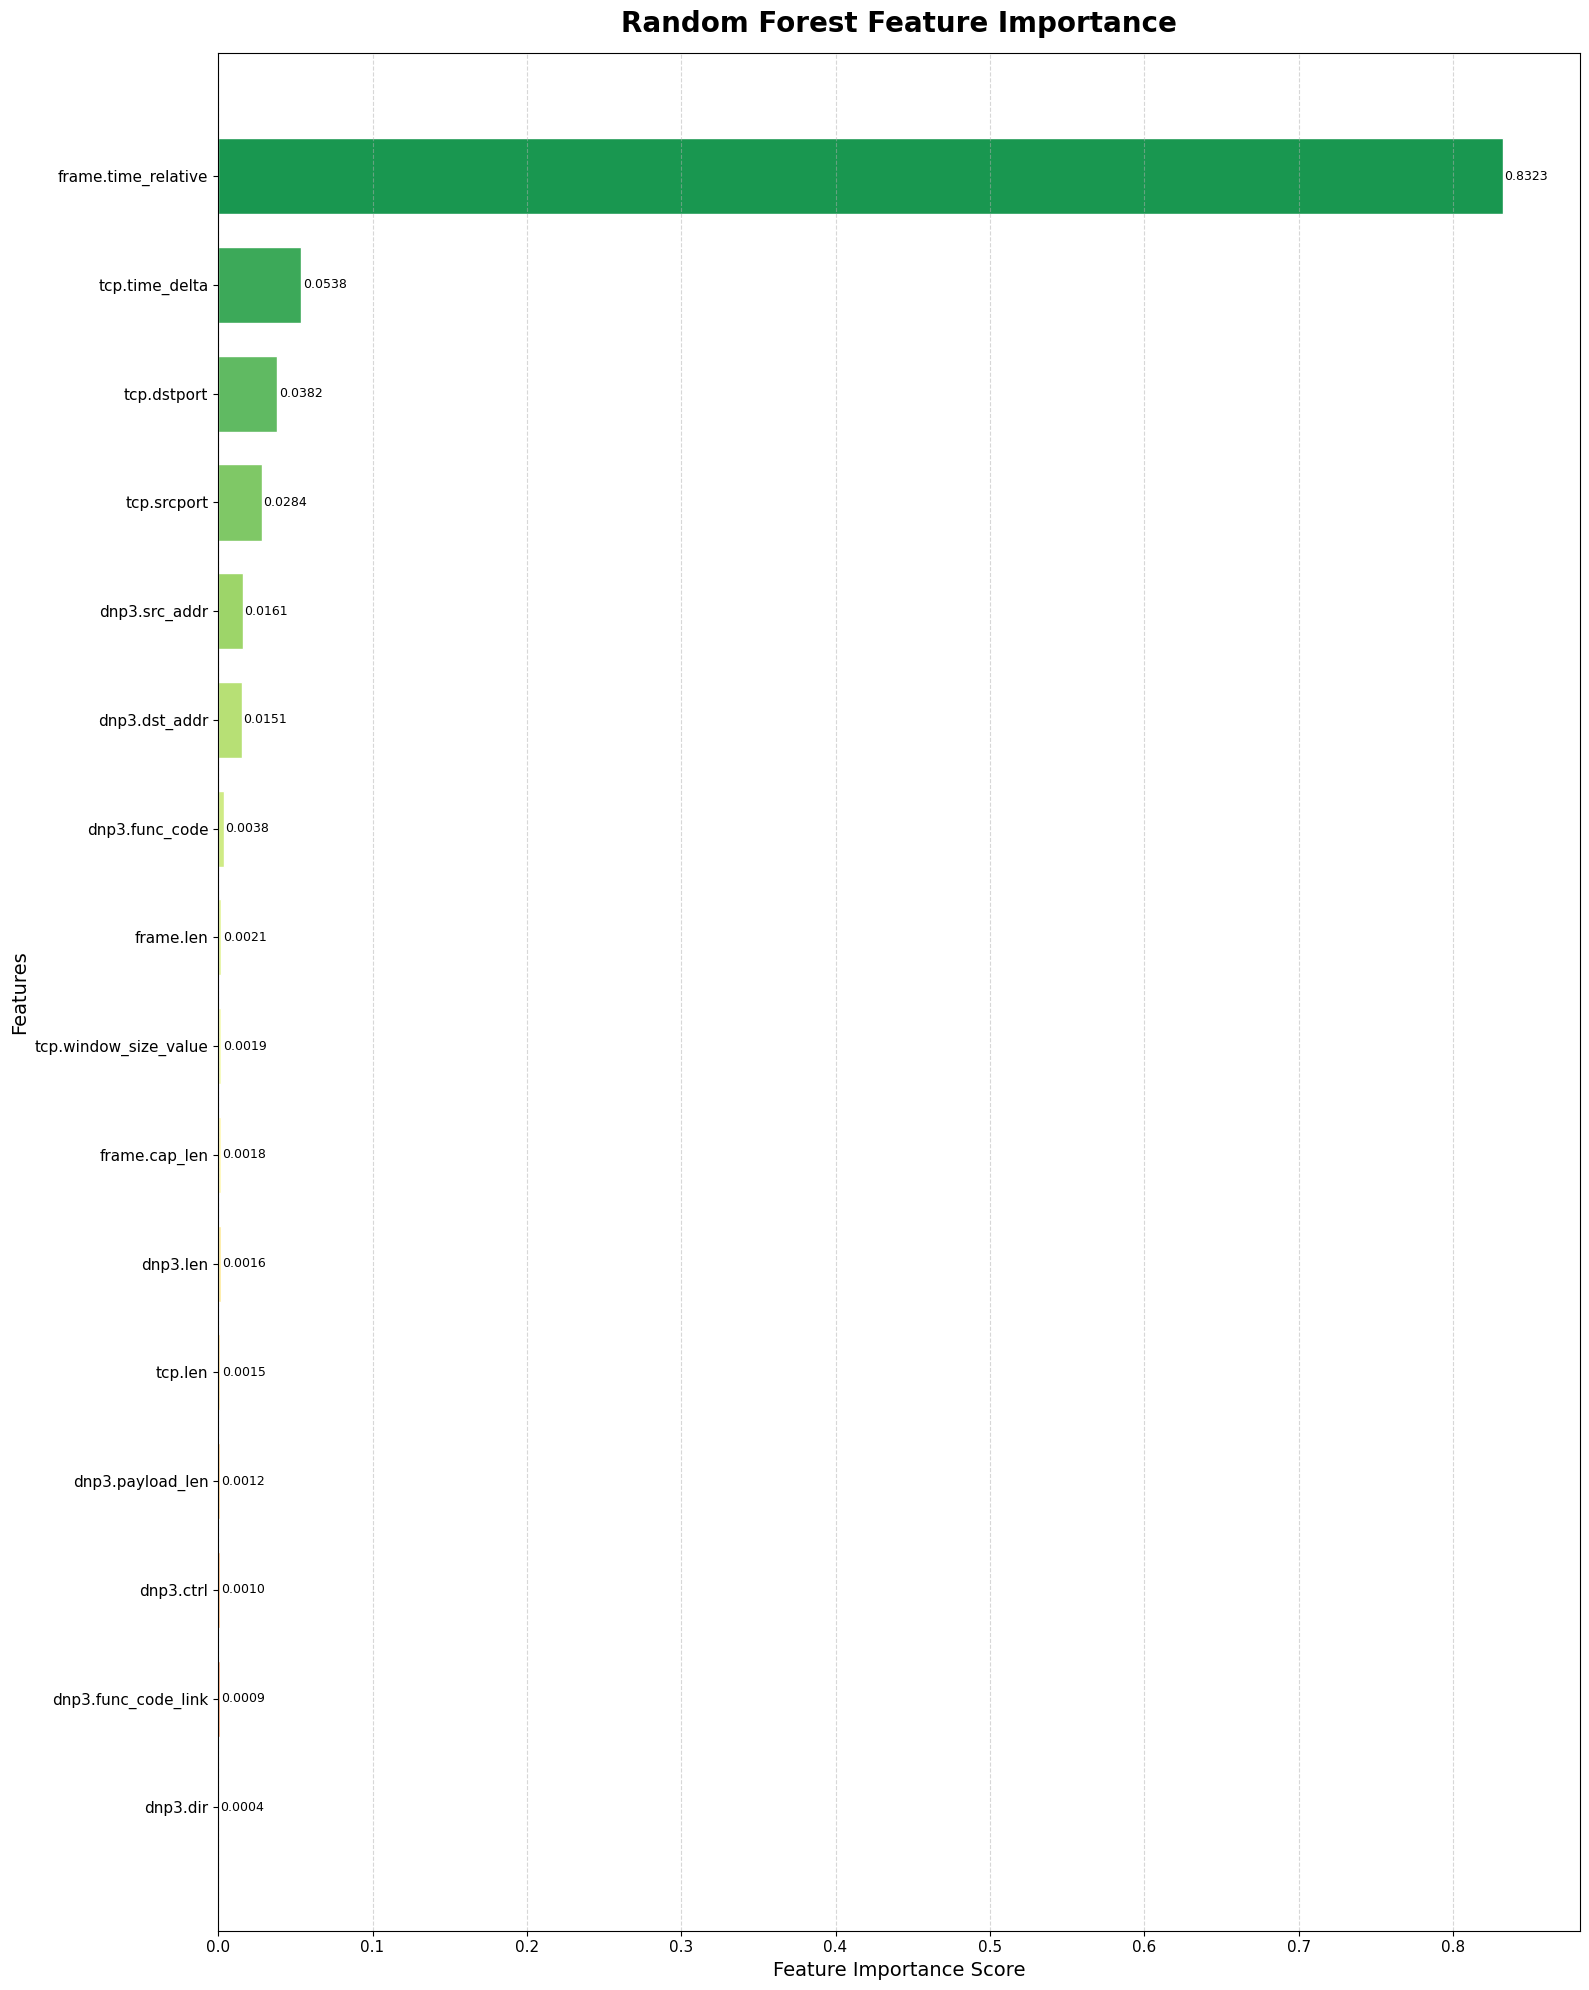

In [47]:
# Get feature importances and sort
feature_importances = rf11.feature_importances_
sorted_idx = feature_importances.argsort()
sorted_features = X_train.columns[sorted_idx]
sorted_values = feature_importances[sorted_idx]

# Color gradient based on importance
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sorted_features)))

plt.figure(figsize=(16, 20))
bars = plt.barh(sorted_features, sorted_values, color=colors, edgecolor='white', height=0.7)

# Add value labels on each bar
for bar, val in zip(bars, sorted_values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', ha='left', fontsize=9, color='black')

# Styling
plt.xlabel('Feature Importance Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.title('Random Forest Feature Importance', fontsize=20, fontweight='bold', pad=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(0, sorted_values.max() + 0.05)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [48]:
# Get top N features
top_n = 10
top_features = f.nlargest(top_n, 'feature importance').index

print("\nTop", top_n, "features:")
print(top_features)


Top 10 features:
Index(['frame.time_relative', 'tcp.time_delta', 'tcp.dstport', 'tcp.srcport',
       'dnp3.src_addr', 'dnp3.dst_addr', 'dnp3.func_code', 'frame.len',
       'tcp.window_size_value', 'frame.cap_len'],
      dtype='object')


In [68]:
top_k_features = top_features.tolist()
top_k_features

['frame.time_relative',
 'tcp.time_delta',
 'tcp.dstport',
 'tcp.srcport',
 'dnp3.src_addr',
 'dnp3.dst_addr',
 'dnp3.func_code',
 'frame.len',
 'tcp.window_size_value',
 'frame.cap_len']

In [69]:
X_train_rf_std = X_train_std[top_k_features]
X_test_rf_std = X_test_std[top_k_features]

### **Model Building**

In [86]:
import time

# Import classifiers
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

#import for preprocessing
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay


# import methods for measuring accuracy, precision, recall etc
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import roc_curve, auc, roc_auc_score

!pip install lightgbm
from lightgbm import LGBMClassifier

In [73]:
def get_results(model, y_pred, y_test, Classes, multi_class=True, label_name='ActualData'):
    if multi_class:
        accuracy = round(accuracy_score(y_pred, y_test)*100,4)
        precision = round(precision_score(y_pred, y_test, average='macro')*100,4)
        recall = round(recall_score(y_pred, y_test, average='macro')*100,4)
        f1_scr = round(f1_score(y_pred, y_test, average='macro')*100,4)
    else:
        accuracy = round(accuracy_score(y_pred, y_test)*100,4)
        precision = round(precision_score(y_pred, y_test)*100,4)
        recall = round(recall_score(y_pred, y_test)*100,4)
        f1_scr = round(f1_score(y_pred, y_test)*100,4)


    print("\nAccuracy: {}%".format(accuracy))
    print("Precision: {}%".format(precision))
    print("Recall: {}%".format(recall))
    print("F1-Score: {}%".format(f1_scr))
    print()
    print("Classification Report:")
    print(classification_report(y_pred, y_test,
                                target_names=Classes
                                ))
    print()
    print("Confusion Matrix:")
    fig, ax = plt.subplots(figsize=(7,5))
    ConfusionMatrixDisplay.from_predictions(y_pred, y_test,
                                            ax=ax,
                                            display_labels=Classes,
                                            xticks_rotation='vertical')
    plt.show()

    return {
        'Model':f"{model.__class__.__name__} ({label_name})",
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1_scr
    }

In [74]:
def model_training(model_object, X, y):
  print("Training ...")
  start_time = time.time()
  model = model_object
  %time model.fit(X, y)
  training_time = time.time() - start_time
  print("training time: ", training_time)
  print(" done.")
  joblib.dump(model_object, f"{model_object}.joblib")
  memory = np.round(os.path.getsize(f"{model_object}.joblib") / 1024 / 1024, 5)
  # print(f"Random Forest size: { rf_memory } MB")
  return model, training_time, memory

In [75]:
def model_predicting(model_objet, X):
  print("Predicting ...")
  s = time.time()
  y_pred = model_objet.predict(X)
  p = time.time() - s
  print("predicted time: ",p)
  print('done')
  print()
  return y_pred, p

In [76]:
def train_model(model_obj, X_train, y_train, X_test):
  model, rf_time, rf_memory = model_training(model_obj, X_train, y_train)
  y_pred1,rf_pred_time = model_predicting(model,X_test)
  return model, rf_time, rf_memory, y_pred1,rf_pred_time

In [77]:
def get_model_results(res):
  # Convert the dictionary to a DataFrame
  return pd.DataFrame.from_dict([res]).set_index('Model')

In [78]:
len(CLASSES)

5

In [87]:
# Calculate the prior probabilities for each class
class_prior = [0.25]*len(CLASSES)
class_prior

MODELS = {
    'RANDOM FOREST MODEL': RandomForestClassifier(class_weight="balanced"),
    'EXTRA TREES MODEL': ExtraTreesClassifier(class_weight="balanced"),
    'LOGISTIC REGRESSION MODEL': LogisticRegression(class_weight="balanced"),
    'NAVIE BAYES MODEL': GaussianNB(),
    'LIGHTGBM MODEL': LGBMClassifier(class_weight="balanced"),
}

MODELS['NAVIE BAYES MODEL'].class_prior_ = class_prior  # Set the calculated prior probabilities

				 RANDOM FOREST MODEL
Training ...
CPU times: user 1min 13s, sys: 101 ms, total: 1min 13s
Wall time: 1min 30s
training time:  90.13742089271545
 done.
Predicting ...
predicted time:  1.225287914276123
done


Accuracy: 100.0%
Precision: 100.0%
Recall: 100.0%
F1-Score: 100.0%

Classification Report:
                precision    recall  f1-score   support

RESTART_ATTACK       1.00      1.00      1.00    102111
CONTROL_ATTACK       1.00      1.00      1.00     63134
    DNP3_RECON       1.00      1.00      1.00       897
 REPLAY_ATTACK       1.00      1.00      1.00       576
    DOS_ATTACK       1.00      1.00      1.00       109

      accuracy                           1.00    166827
     macro avg       1.00      1.00      1.00    166827
  weighted avg       1.00      1.00      1.00    166827


Confusion Matrix:


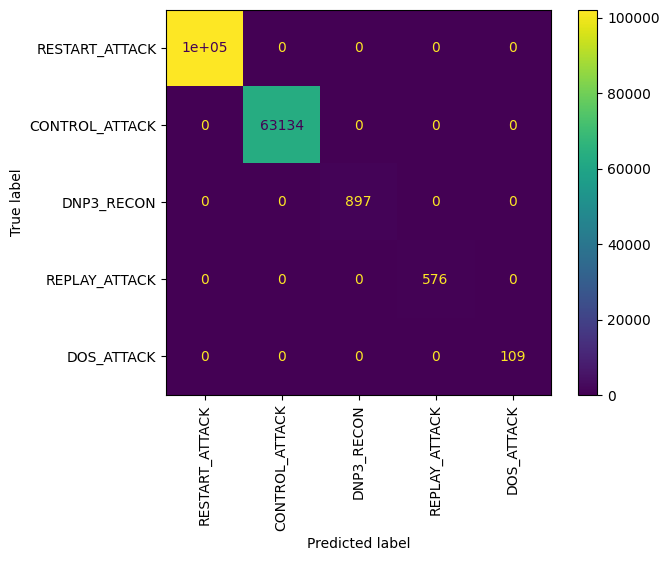

				 EXTRA TREES MODEL
Training ...
CPU times: user 31.7 s, sys: 41.7 ms, total: 31.7 s
Wall time: 32.5 s
training time:  32.52411341667175
 done.
Predicting ...
predicted time:  1.1309502124786377
done


Accuracy: 100.0%
Precision: 100.0%
Recall: 100.0%
F1-Score: 100.0%

Classification Report:
                precision    recall  f1-score   support

RESTART_ATTACK       1.00      1.00      1.00    102111
CONTROL_ATTACK       1.00      1.00      1.00     63134
    DNP3_RECON       1.00      1.00      1.00       897
 REPLAY_ATTACK       1.00      1.00      1.00       576
    DOS_ATTACK       1.00      1.00      1.00       109

      accuracy                           1.00    166827
     macro avg       1.00      1.00      1.00    166827
  weighted avg       1.00      1.00      1.00    166827


Confusion Matrix:


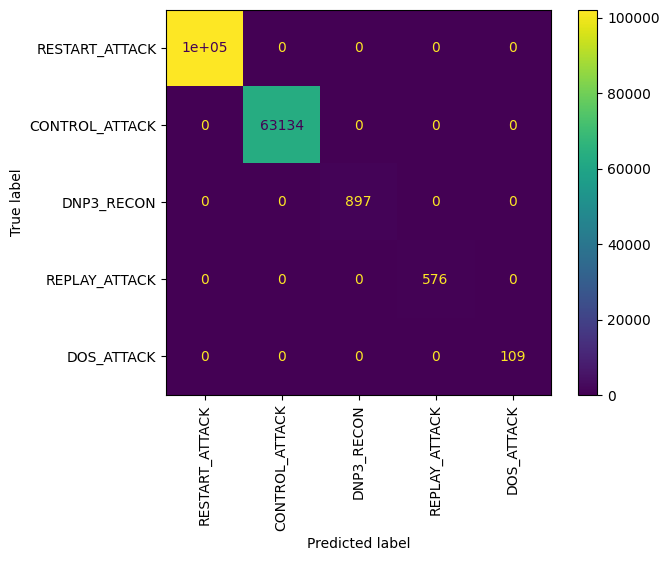

				 LOGISTIC REGRESSION MODEL
Training ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


CPU times: user 36 s, sys: 73.8 ms, total: 36.1 s
Wall time: 24.6 s
training time:  24.570847749710083
 done.
Predicting ...
predicted time:  0.016446352005004883
done


Accuracy: 54.1921%
Precision: 81.7101%
Recall: 53.0693%
F1-Score: 55.9367%

Classification Report:
                precision    recall  f1-score   support

RESTART_ATTACK       0.52      0.69      0.59     76622
CONTROL_ATTACK       0.56      0.43      0.49     82629
    DNP3_RECON       1.00      1.00      1.00       897
 REPLAY_ATTACK       1.00      0.51      0.67      1133
    DOS_ATTACK       1.00      0.02      0.04      5546

      accuracy                           0.54    166827
     macro avg       0.82      0.53      0.56    166827
  weighted avg       0.56      0.54      0.53    166827


Confusion Matrix:


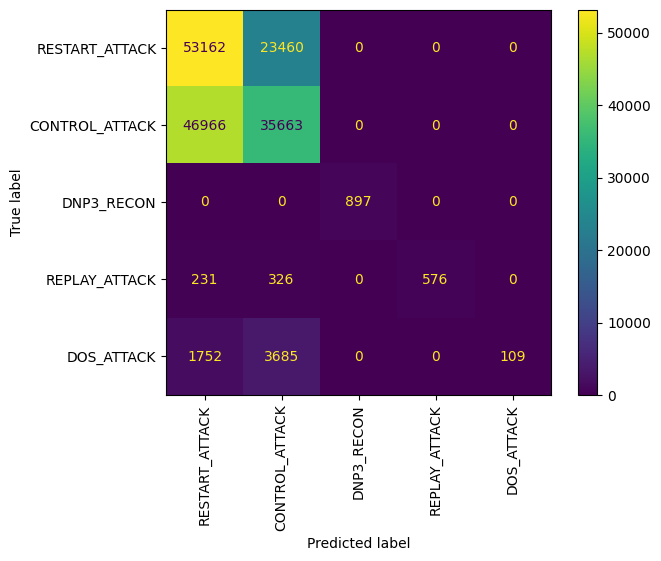

				 NAVIE BAYES MODEL
Training ...
CPU times: user 174 ms, sys: 21.9 ms, total: 196 ms
Wall time: 198 ms
training time:  0.19883060455322266
 done.
Predicting ...
predicted time:  0.05041027069091797
done


Accuracy: 98.9096%
Precision: 55.3653%
Recall: 74.6153%
F1-Score: 57.7706%

Classification Report:
                precision    recall  f1-score   support

RESTART_ATTACK       0.99      1.00      1.00    101512
CONTROL_ATTACK       1.00      0.98      0.99     63995
    DNP3_RECON       0.49      0.42      0.45      1037
 REPLAY_ATTACK       0.15      0.32      0.21       268
    DOS_ATTACK       0.14      1.00      0.24        15

      accuracy                           0.99    166827
     macro avg       0.55      0.75      0.58    166827
  weighted avg       0.99      0.99      0.99    166827


Confusion Matrix:


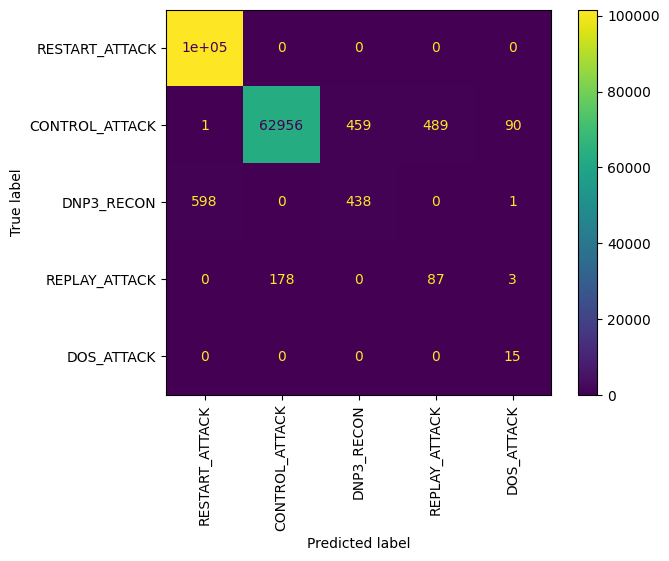

				 LIGHTGBM MODEL
Training ...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022761 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1049
[LightGBM] [Info] Number of data points in the train set: 667305, number of used features: 10
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
CPU times: user 23.2 s, sys: 67.6 ms, total: 23.3 s
Wall time: 23.5 s
training time:  23.50510025024414
 done.
Predict

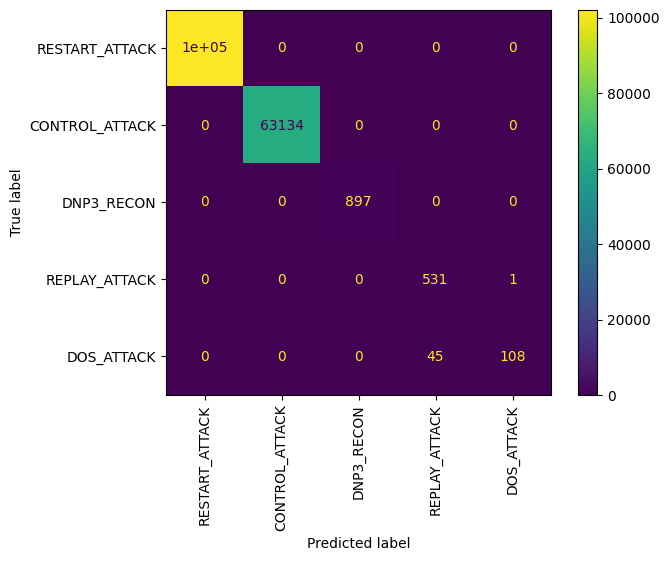

In [89]:
FINAL_RES_rf = []
for model_name, model_obj in MODELS.items():
  print("="*100)
  print(f"\t\t\t\t {model_name}")
  print("="*100)
  model, rf_time, rf_memory, y_pred1, rf_pred_time = train_model(model_obj, X_train_rf_std, y_train, X_test_rf_std)

  RESULTS = get_results(model, y_pred1.astype(int), y_test, CLASSES, multi_class=True, label_name='RF')
  RESULTS['trainingTime'] = rf_time
  RESULTS['predTime'] = rf_pred_time
  RESULTS['memoryUsage(MB)'] = rf_memory
  results_rf = get_model_results(RESULTS)
  FINAL_RES_rf.append(results_rf)

In [90]:
df_all_models = pd.concat(FINAL_RES_rf)
models_pd_4 = df_all_models.reset_index()
models_pd_4

,Model,Accuracy,Precision,Recall,F1,trainingTime,predTime,memoryUsage(MB)
0,RandomForestClassifier (RF),100.0000,100.0000,100.0000,100.0000,90.137421,1.225288,1.17708
1,ExtraTreesClassifier (RF),100.0000,100.0000,100.0000,100.0000,32.524113,1.130950,4.37947
2,LogisticRegression (RF),54.1921,81.7101,53.0693,55.9367,24.570848,0.016446,0.00168
3,GaussianNB (RF),98.9096,55.3653,74.6153,57.7706,0.198831,0.050410,0.00198
4,LGBMClassifier (RF),99.9724,98.2540,94.0801,95.6582,23.505100,3.356442,1.70536


### KAN

In [93]:
!pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 2.1 MB/s eta 0:00:00


In [94]:
from kan import KAN
import torch

In [95]:
def make_dataset_for_KAN(X_train_scaled, X_test_scaled, y_train, y_test):
    """
    Converts scaled training and testing datasets into PyTorch tensors.

    Parameters:
    - X_train_scaled: Scaled training input features (Pandas DataFrame or NumPy array).
    - X_test_scaled: Scaled testing input features (Pandas DataFrame or NumPy array).
    - y_train: Training labels (Pandas Series or DataFrame).
    - y_test: Testing labels (Pandas Series or DataFrame).

    Returns:
    - dataset: A dictionary containing training and testing inputs and labels as PyTorch tensors.
    """
    # Initialize an empty dictionary to hold the dataset
    dataset = {}

    # Convert the training input data from NumPy array to PyTorch tensor and store it in the dataset dictionary
    dataset['train_input'] = torch.from_numpy(X_train_scaled.values).float()

    # Convert the test input data from NumPy array to PyTorch tensor and store it in the dataset dictionary
    dataset['test_input'] = torch.from_numpy(X_test_scaled.values).float()

    # Convert the training labels from a pandas Series or DataFrame to a PyTorch tensor and store it in the dataset dictionary
    dataset['train_label'] = torch.from_numpy(y_train.values)

    # Convert the test labels from a pandas Series or DataFrame to a PyTorch tensor and store it in the dataset dictionary
    dataset['test_label'] = torch.from_numpy(y_test.values)

    return dataset

In [100]:
def check_in_out_features(X_train_scaled, y_train):
  input_features = X_train_scaled.shape[1]
  output = len(np.unique(y_train))

  return input_features, output

In [104]:
def fit_KAN_model(model, dataset):
  # Function to calculate training accuracy
  def train_acc():
      # Calculate the mean accuracy for training data
      return torch.mean((torch.argmax(model(dataset['train_input']), dim=1) == dataset['train_label']).float())

  # Function to calculate test accuracy
  def test_acc():
      # Calculate the mean accuracy for test data
      return torch.mean((torch.argmax(model(dataset['test_input']), dim=1) == dataset['test_label']).float())

  # Function to calculate training precision
  def train_precision():
      preds = torch.argmax(model(dataset['train_input']), dim=1)  # Get predictions
      true_positives = torch.sum((preds == 1) & (dataset['train_label'] == 1))  # Count true positives
      predicted_positives = torch.sum(preds == 1)  # Count predicted positives
      return true_positives.float() / predicted_positives.float()  # Calculate precision

  # Function to calculate training recall
  def train_recall():
      preds = torch.argmax(model(dataset['train_input']), dim=1)  # Get predictions
      true_positives = torch.sum((preds == 1) & (dataset['train_label'] == 1))  # Count true positives
      actual_positives = torch.sum(dataset['train_label'] == 1)  # Count actual positives
      return true_positives.float() / actual_positives.float()  # Calculate recall

  # Function to calculate training F1 score
  def train_f1():
      precision = train_precision()  # Get precision
      recall = train_recall()  # Get recall
      return 2 * (precision * recall) / (precision + recall)  # Calculate F1 score

  # Function to calculate test precision
  def test_precision():
      preds = torch.argmax(model(dataset['test_input']), dim=1)  # Get predictions
      true_positives = torch.sum((preds == 1) & (dataset['test_label'] == 1))  # Count true positives
      predicted_positives = torch.sum(preds == 1)  # Count predicted positives
      return true_positives.float() / predicted_positives.float()  # Calculate precision

  # Function to calculate test recall
  def test_recall():
      preds = torch.argmax(model(dataset['test_input']), dim=1)  # Get predictions
      true_positives = torch.sum((preds == 1) & (dataset['test_label'] == 1))  # Count true positives
      actual_positives = torch.sum(dataset['test_label'] == 1)  # Count actual positives
      return true_positives.float() / actual_positives.float()  # Calculate recall

  # Function to calculate test F1 score
  def test_f1():
      precision = test_precision()  # Get precision
      recall = test_recall()  # Get recall
      return 2 * (precision * recall) / (precision + recall)  # Calculate F1 score


  # Function to get memory usage in MB
  def get_memory_usage_mb():
      process = psutil.Process()
      mem_info = process.memory_info()
      return mem_info.rss / (1024 * 1024)  # Convert bytes to MB


  # Measure memory usage before training
  if torch.cuda.is_available():
      mem_before_training = torch.cuda.memory_allocated() / (1024 ** 2)  # Convert bytes to MB
  else:
      mem_before_training = get_memory_usage_mb()

  # Measure training time
  start_time = time.time()


  # train the model
  results = model.fit(
      dataset,
      opt="LBFGS",
      steps=2,
      metrics=(train_acc, test_acc, train_precision, train_recall, train_f1, test_precision, test_recall, test_f1),
      loss_fn=torch.nn.CrossEntropyLoss()
  )


  end_time = time.time()

  # Measure memory usage after training
  if torch.cuda.is_available():
      mem_after_training = torch.cuda.memory_allocated() / (1024 ** 2)  # Convert bytes to MB
  else:
      mem_after_training = get_memory_usage_mb()

  # Calculate time taken for training
  training_time = end_time - start_time

  # Print results
  print(f"\nTraining Time: {training_time} seconds")

  if torch.cuda.is_available():
      print(f"Memory Usage Before Training: {mem_before_training:.2f} MB")
      print(f"Memory Usage After Training: {mem_after_training:.2f} MB")
  else:
      print(f"Memory Usage Before Training: {mem_before_training:.2f} MB")
      print(f"Memory Usage After Training: {mem_after_training:.2f} MB")

  return results, training_time, mem_after_training

In [107]:
def get_prediction(dataset):
  start_time = time.time()

  # get prediction on testing dataset
  y_pred = torch.argmax(model(dataset['test_input']), dim=1).cpu().detach().numpy()

  end_time = time.time()

  # Calculate time taken for training
  predicting_time = end_time - start_time

  return y_pred, predicting_time

In [108]:
def performance_metrics(y_pred, dataset, Classes):
  # Classes = ['Normal', 'Attack']

  print("Classification Report:")
  print(classification_report(y_pred, dataset['test_label'].cpu().detach().numpy(),
                              target_names=Classes
                              ))
  print()
  print("Confusion Matrix:")

  fig, ax = plt.subplots(figsize=(7,5))
  ConfusionMatrixDisplay.from_predictions(y_pred, dataset['test_label'].cpu().detach().numpy(),
                                      ax=ax,
                                      display_labels=Classes,
                                      xticks_rotation='vertical')
  plt.show()

In [109]:
def KAN_evlation(dataset_name='Uni-Flow'):
  dic = {
    'Model':f'KAN ({dataset_name})',
    'Accuracy': round(np.mean(results['test_acc'])*100, 2),
    'Precision': round(np.mean(results['test_precision'])*100, 2),
    'Recall': round(np.mean(results['test_recall'])*100, 2),
    'F1': round(np.mean(results['test_f1'])*100,2),
    'trainingTime': training_time,
    'predTime': predicting_time,
    'memoryUsage(MB)': mem_after_training
}

  # Make a dataframe
  kan_res = pd.DataFrame(dic, index=[0])
  return kan_res

In [96]:
top_k_features

['frame.time_relative',
 'tcp.time_delta',
 'tcp.dstport',
 'tcp.srcport',
 'dnp3.src_addr',
 'dnp3.dst_addr',
 'dnp3.func_code',
 'frame.len',
 'tcp.window_size_value',
 'frame.cap_len']

In [97]:
dataset = make_dataset_for_KAN(X_train_rf_std,
                               X_test_rf_std, y_train, y_test)

In [98]:
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([667305, 10]), torch.Size([667305]))

In [101]:
input_features,output = check_in_out_features(X_train_rf_std, y_train)
input_features, output

(10, 5)

In [102]:
import psutil

# KAN is a predefined model class
model = KAN(width=[input_features, output], grid=3, k=3)

checkpoint directory created: ./model
saving model version 0.0


In [105]:
results, training_time, mem_after_training  = fit_KAN_model(model, dataset)

| train_loss: 2.12e-02 | test_loss: 6.31e-02 | reg: 1.02e+03 | : 100%|█| 2/2 [09:51<00:00, 295.53s/i


saving model version 0.1

Training Time: 591.3381686210632 seconds
Memory Usage Before Training: 2487.04 MB
Memory Usage After Training: 3260.22 MB


Classification Report:
                precision    recall  f1-score   support

RESTART_ATTACK       1.00      1.00      1.00    102112
CONTROL_ATTACK       1.00      1.00      1.00     63134
    DNP3_RECON       1.00      1.00      1.00       897
 REPLAY_ATTACK       1.00      0.95      0.97       609
    DOS_ATTACK       0.69      1.00      0.82        75

      accuracy                           1.00    166827
     macro avg       0.94      0.99      0.96    166827
  weighted avg       1.00      1.00      1.00    166827


Confusion Matrix:


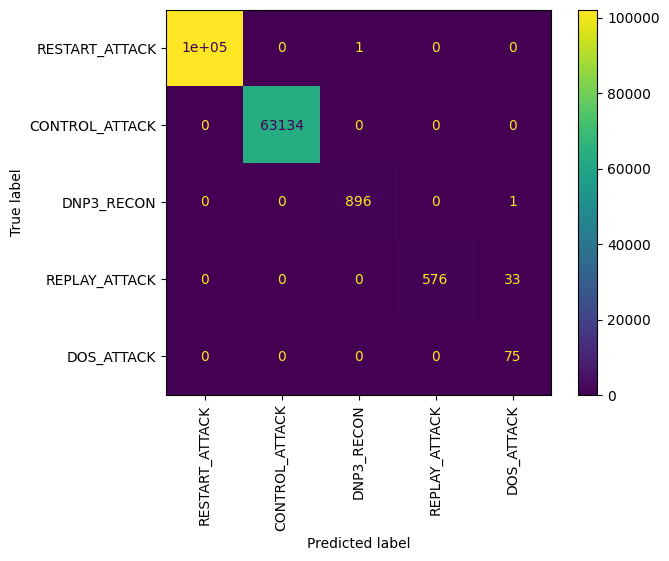

In [110]:
y_pred, predicting_time = get_prediction(dataset)
performance_metrics(y_pred, dataset, CLASSES)

In [111]:
kan_res = KAN_evlation(dataset_name='RF')
kan_res

,Model,Accuracy,Precision,Recall,F1,trainingTime,predTime,memoryUsage(MB)
0,KAN (RF),99.88,99.76,100.0,99.88,591.338169,1.165784,3260.222656


In [114]:
FINAL_RES_RF = pd.concat([models_pd_4, kan_res]).sort_values(by='F1', ascending=False).reset_index(drop=True)
FINAL_RES_RF

,Model,Accuracy,Precision,Recall,F1,trainingTime,predTime,memoryUsage(MB)
0,RandomForestClassifier (RF),100.0000,100.0000,100.0000,100.0000,90.137421,1.225288,1.177080
1,ExtraTreesClassifier (RF),100.0000,100.0000,100.0000,100.0000,32.524113,1.130950,4.379470
2,KAN (RF),99.8800,99.7600,100.0000,99.8800,591.338169,1.165784,3260.222656
3,LGBMClassifier (RF),99.9724,98.2540,94.0801,95.6582,23.505100,3.356442,1.705360
4,GaussianNB (RF),98.9096,55.3653,74.6153,57.7706,0.198831,0.050410,0.001980
5,LogisticRegression (RF),54.1921,81.7101,53.0693,55.9367,24.570848,0.016446,0.001680


In [117]:
def model_evaluation_graph(models_pd_):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    sns.set_theme(style="whitegrid", font_scale=1.05)

    perf_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
    cost_metrics = ['trainingTime', 'predTime', 'memoryUsage(MB)']

    models = models_pd_['Model'].tolist()
    n_models = len(models)
    palette = sns.color_palette("Set2", n_models)

    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3, height_ratios=[1.2, 1])

    # ---- 1. Grouped bar chart: performance metrics ----
    ax1 = fig.add_subplot(gs[0, :])
    x = np.arange(len(perf_metrics))
    width = 0.8 / n_models

    for i, model in enumerate(models):
        values = models_pd_.loc[models_pd_['Model'] == model, perf_metrics].values.flatten()
        bars = ax1.bar(x + i * width, values, width, label=model, color=palette[i], edgecolor='white')
        for bar, val in zip(bars, values):
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                      f'{val:.1f}', ha='center', va='bottom', fontsize=8)

    ax1.set_xticks(x + width * (n_models - 1) / 2)
    ax1.set_xticklabels(perf_metrics)
    ax1.set_ylim(0, 105)
    ax1.set_ylabel('Score (%)')
    ax1.set_title('Performance Metrics by Model', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=n_models, frameon=False)
    ax1.spines[['top', 'right']].set_visible(False)

    # ---- 2-4. Cost metrics: training time, prediction time, memory ----
    cost_titles = ['Training Time (s)', 'Prediction Time (s)', 'Memory Usage (MB)']
    tick_pos = np.arange(n_models)

    for idx, (metric, title) in enumerate(zip(cost_metrics, cost_titles)):
        ax = fig.add_subplot(gs[1, idx])
        values = models_pd_[metric].values
        bars = ax.bar(tick_pos, values, color=palette, edgecolor='white')
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                     f'{val:.2f}', ha='center', va='bottom', fontsize=8)
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(models, rotation=30, ha='right', fontsize=8)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle('Model Performance & Efficiency Comparison', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ---- 5. Heatmap: quick scan of all metrics together ----
    all_metrics = perf_metrics + cost_metrics
    heat_df = models_pd_.set_index('Model')[all_metrics]
    heat_norm = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min())

    plt.figure(figsize=(10, 0.6 * n_models + 2))
    sns.heatmap(heat_norm, annot=heat_df.round(2), fmt='', cmap='YlGnBu',
                cbar_kws={'label': 'Normalized Score'}, linewidths=0.5)
    plt.title('Metric Heatmap (normalized, raw values annotated)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

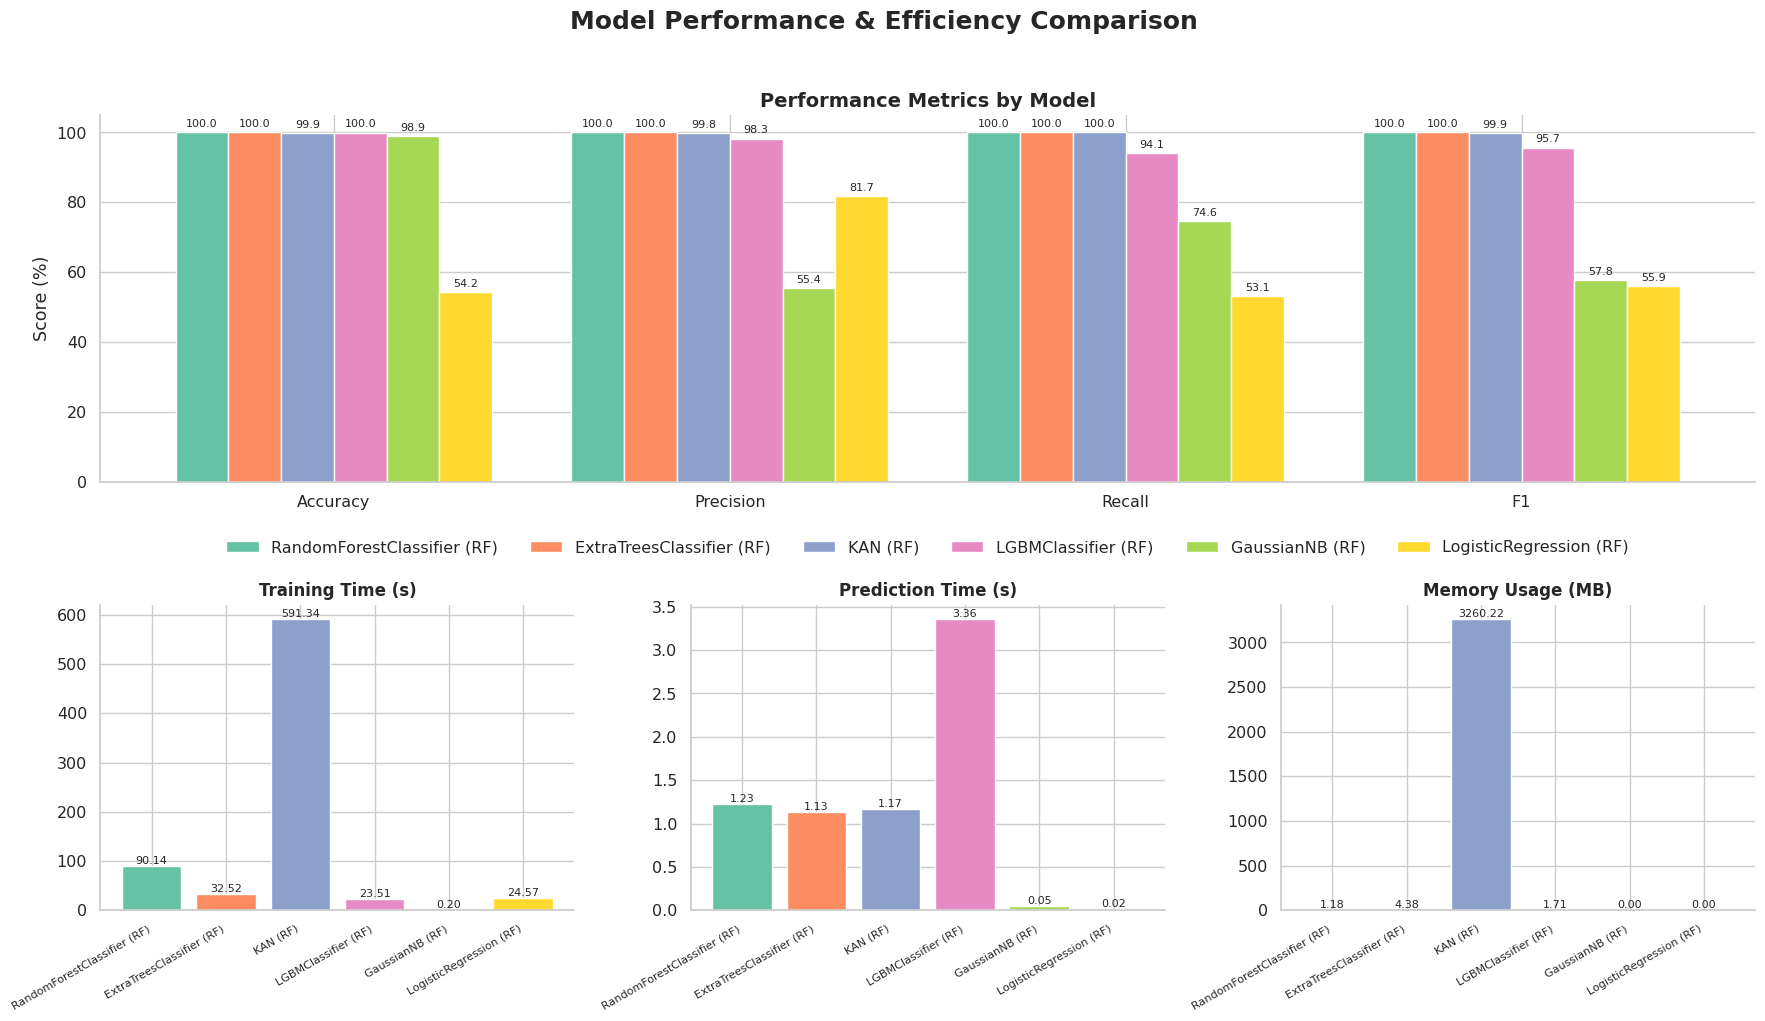

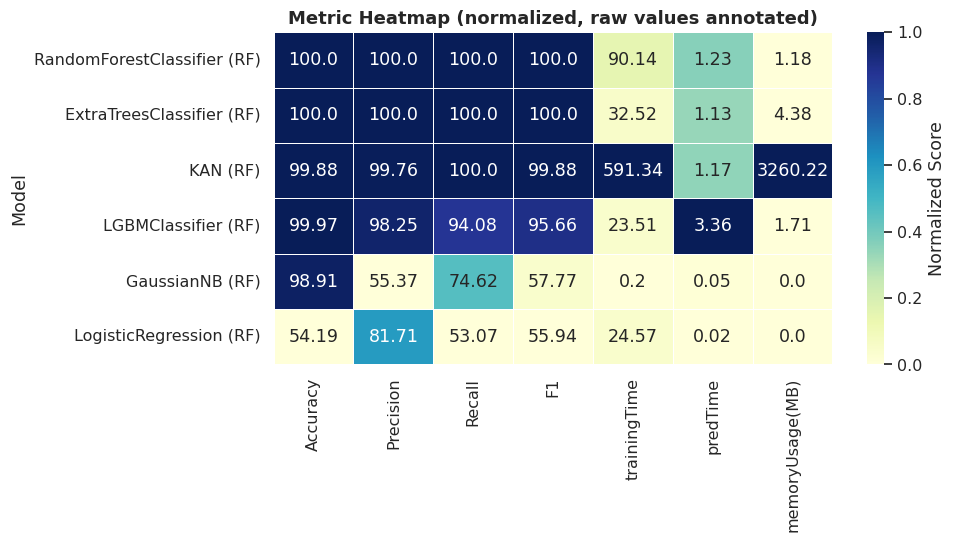

In [118]:
model_evaluation_graph(FINAL_RES_RF)

In [119]:
df_train_rf = pd.DataFrame(X_train_rf_std, columns=top_k_features)
df_test_rf = pd.DataFrame(X_test_rf_std, columns=top_k_features)

In [120]:
fullData = pd.concat([df_train_rf, df_test_rf])
fullLabel = pd.concat([y_train, y_test])

fullData.shape, fullLabel.shape

((834132, 10), (834132,))

In [121]:
fullData.head()

,frame.time_relative,tcp.time_delta,tcp.dstport,tcp.srcport,dnp3.src_addr,dnp3.dst_addr,dnp3.func_code,frame.len,tcp.window_size_value,frame.cap_len
0,0.159552,0.002465,-0.929246,0.806653,-0.889944,0.937513,-0.996179,-0.140655,1.205312,-0.140655
1,-0.046482,0.002267,-0.929319,0.055101,-1.053052,0.937513,-0.996179,-0.140655,1.205312,-0.140655
2,-0.092886,0.000564,1.630849,-0.903655,1.067356,-0.856002,1.014475,-0.156138,-0.919672,-0.156138
3,0.055358,0.000564,1.659153,-0.903655,1.230464,-0.856002,1.014475,-0.156138,-0.919672,-0.156138
4,-0.029642,0.000564,-0.929246,1.795456,-0.889944,0.611419,-0.807680,-0.187103,1.205312,-0.187103


In [122]:
fullLabel.head()

,Label_Grouped
491928,0
94813,0
184944,0
407893,0
236022,0


### Saving And Loading Model

In [123]:
import pickle
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

# === Train Model ===
best_model = RandomForestClassifier(class_weight='balanced')
best_model.fit(fullData, fullLabel)

# === Predictions ===
y_pred = best_model.predict(fullData)
print(classification_report(fullLabel, y_pred))   # (true, pred) order is better here

# === Save Model ===
with open(f"{directory_path}/DNP3_RF_best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("✅ Model saved as best_model.pkl")

# === Load Model ===
with open(f"{directory_path}/DNP3_RF_best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# === Test Loaded Model ===
y_loaded_pred = loaded_model.predict(fullData)
print("✅ Loaded model works the same")
print(classification_report(fullLabel, y_loaded_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    510551
           1       1.00      1.00      1.00    315671
           2       1.00      1.00      1.00      4483
           3       1.00      1.00      1.00      2882
           4       1.00      1.00      1.00       545

    accuracy                           1.00    834132
   macro avg       1.00      1.00      1.00    834132
weighted avg       1.00      1.00      1.00    834132

✅ Model saved as best_model.pkl
✅ Loaded model works the same
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    510551
           1       1.00      1.00      1.00    315671
           2       1.00      1.00      1.00      4483
           3       1.00      1.00      1.00      2882
           4       1.00      1.00      1.00       545

    accuracy                           1.00    834132
   macro avg       1.00      1.00      1.00    834132
weighted avg   

### Get Prediction

In [124]:
fullData.columns

Index(['frame.time_relative', 'tcp.time_delta', 'tcp.dstport', 'tcp.srcport',
       'dnp3.src_addr', 'dnp3.dst_addr', 'dnp3.func_code', 'frame.len',
       'tcp.window_size_value', 'frame.cap_len'],
      dtype='object')

In [125]:
top_k_features

['frame.time_relative',
 'tcp.time_delta',
 'tcp.dstport',
 'tcp.srcport',
 'dnp3.src_addr',
 'dnp3.dst_addr',
 'dnp3.func_code',
 'frame.len',
 'tcp.window_size_value',
 'frame.cap_len']

In [126]:
Training_features = ['frame.time_relative',
 'tcp.time_delta',
 'tcp.dstport',
 'tcp.srcport',
 'dnp3.src_addr',
 'dnp3.dst_addr',
 'dnp3.func_code',
 'frame.len',
 'tcp.window_size_value',
 'frame.cap_len']

In [140]:
fullData.columns

Index(['frame.time_relative', 'tcp.time_delta', 'tcp.dstport', 'tcp.srcport',
       'dnp3.src_addr', 'dnp3.dst_addr', 'dnp3.func_code', 'frame.len',
       'tcp.window_size_value', 'frame.cap_len'],
      dtype='object')

In [141]:
fullData.head()

,frame.time_relative,tcp.time_delta,tcp.dstport,tcp.srcport,dnp3.src_addr,dnp3.dst_addr,dnp3.func_code,frame.len,tcp.window_size_value,frame.cap_len
0,0.159552,0.002465,-0.929246,0.806653,-0.889944,0.937513,-0.996179,-0.140655,1.205312,-0.140655
1,-0.046482,0.002267,-0.929319,0.055101,-1.053052,0.937513,-0.996179,-0.140655,1.205312,-0.140655
2,-0.092886,0.000564,1.630849,-0.903655,1.067356,-0.856002,1.014475,-0.156138,-0.919672,-0.156138
3,0.055358,0.000564,1.659153,-0.903655,1.230464,-0.856002,1.014475,-0.156138,-0.919672,-0.156138
4,-0.029642,0.000564,-0.929246,1.795456,-0.889944,0.611419,-0.807680,-0.187103,1.205312,-0.187103


In [158]:
INPUT = X.iloc[0].to_dict()
INPUT

{'frame.time_relative': 0.000756025314331,
 'frame.len': 83.0,
 'frame.cap_len': 83.0,
 'tcp.srcport': 20001.0,
 'tcp.dstport': 41538.0,
 'tcp.len': 17.0,
 'tcp.window_size_value': 227.0,
 'tcp.time_delta': 0.000756025314331,
 'dnp3.len': 10.0,
 'dnp3.ctrl': 68.0,
 'dnp3.dst_addr': 2.0,
 'dnp3.src_addr': 13.0,
 'dnp3.dir': 0.0,
 'dnp3.func_code_link': 4.0,
 'dnp3.func_code': 129.0,
 'dnp3.payload_len': 17.0}

In [159]:
INPUT = pd.DataFrame([INPUT])
INPUT

,frame.time_relative,frame.len,frame.cap_len,tcp.srcport,tcp.dstport,tcp.len,tcp.window_size_value,tcp.time_delta,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.func_code_link,dnp3.func_code,dnp3.payload_len
0,0.000756,83.0,83.0,20001.0,41538.0,17.0,227.0,0.000756,10.0,68.0,2.0,13.0,0.0,4.0,129.0,17.0


In [160]:
with open(f"{directory_path}/dnp3_scaler_for_SL.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)

In [161]:
# Define class labels in the same order as training
CLASSES = ["RESTART_ATTACK", "CONTROL_ATTACK", "DNP3_RECON", "REPLAY_ATTACK", "DOS_ATTACK"]

def get_prediction(input_data, loaded_model, loaded_scaler, training_features):
    """
    input_data: array-like (1D list/NumPy array for a single sample)
    loaded_model: previously loaded ML model
    loaded_scaler: previously loaded scaler
    training_features: ordered list of feature names used during training
    """
    # Scale the input
    input_scaled = loaded_scaler.transform(input_data)

    # Create DataFrame with proper columns
    INPUT_std_df = pd.DataFrame(
        input_scaled,
        columns=['frame.time_relative', 'frame.len', 'frame.cap_len', 'tcp.srcport',
       'tcp.dstport', 'tcp.len', 'tcp.window_size_value', 'tcp.time_delta',
       'dnp3.len', 'dnp3.ctrl', 'dnp3.dst_addr', 'dnp3.src_addr', 'dnp3.dir',
       'dnp3.func_code_link', 'dnp3.func_code', 'dnp3.payload_len']
    )[training_features]

    # Predict probabilities
    y_proba = loaded_model.predict_proba(INPUT_std_df)[0]

    # Convert to Python floats
    y_proba = y_proba.astype(float)

    # Predicted class index
    y_pred_idx = y_proba.argmax()

    # Map index to class name
    predicted_label = CLASSES[y_pred_idx]
    predicted_prob = float(y_proba[y_pred_idx])

    return {
        "predicted_label": predicted_label,
        "probability": round(predicted_prob, 4)*100,
        "all_probabilities": {cls: round(float(p), 4)*100 for cls, p in zip(CLASSES, y_proba)}
    }


In [162]:
get_prediction(INPUT, loaded_model, loaded_scaler, Training_features)

{'predicted_label': 'RESTART_ATTACK',
 'probability': 100.0,
 'all_probabilities': {'RESTART_ATTACK': 100.0,
  'CONTROL_ATTACK': 0.0,
  'DNP3_RECON': 0.0,
  'REPLAY_ATTACK': 0.0,
  'DOS_ATTACK': 0.0}}